# Práctica numérica 3 - AV18012

## Ecuaciones de Euler para un fluido ideal compresible

Las **ecuaciones de Euler** describen la evolución de un fluido ideal (sin viscosidad ni conducción
térmica). Son fuertemente no lineales y pueden desarrollar **discontinuidades (ondas de choque)**
incluso partiendo de condiciones iniciales suaves. Aparecen en:

- Aerodinámica (flujo sobre perfiles alares)
- Astrofísica estelar (supernovas, vientos estelares)
- Cosmología numérica (formación de estructura)
- Física de plasmas (confinamiento magnético)
- Dinámica atmosférica (pronóstico del tiempo)

En este notebook resolvemos el sistema 1D en **forma conservativa** usando el esquema de
**Lax-Friedrichs**, y estudiamos siete fenómenos: ondas sonoras lineales, efecto Doppler,
propagación bidireccional, conservación de integrales, convergencia numérica, estabilidad
y régimen no lineal.

In [67]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## Marco teórico

### Ecuaciones de Euler 1D

Las ecuaciones de continuidad, momento y energía son

$$
\frac{\partial\rho}{\partial t} + \frac{\partial(\rho v)}{\partial x} = 0,
$$

$$
\frac{\partial(\rho v)}{\partial t} + \frac{\partial(\rho v^2 + p)}{\partial x} = 0,
$$

$$
\frac{\partial E}{\partial t} + \frac{\partial[(E+p)v]}{\partial x} = 0,
$$

donde la densidad de energía total es

$$
E = \rho\left(\epsilon + \frac{v^2}{2}\right),
$$

y la ecuación de estado del gas ideal es

$$
p = (\gamma - 1)\rho\epsilon, \qquad \gamma = \frac{5}{3}.
$$

### Forma conservativa

Definimos el vector de variables conservativas y el vector de flujos:

$$
U = \begin{pmatrix} \rho \\ \rho v \\ E \end{pmatrix}, \qquad
F = \begin{pmatrix} \rho v \\ \rho v^2 + p \\ (E+p)v \end{pmatrix}.
$$

El sistema se escribe compactamente como

$$
\frac{\partial U}{\partial t} + \frac{\partial F}{\partial x} = 0.
$$

### Esquema de Lax-Friedrichs

$$
U_j^{n+1} = \frac{1}{2}\left(U_{j+1}^n + U_{j-1}^n\right)
- \frac{\Delta t}{2\Delta x}\left(F_{j+1}^n - F_{j-1}^n\right).
$$

El promedio espacial introduce difusión numérica artificial que estabiliza la evolución.

En todas las simulaciones usamos condiciones de frontera periódicas. Son consistentes con una perturbación que abarca una longitud de onda completa del dominio y hacen que la masa, el momento y la energía totales se conserven de forma exacta.

### Condición CFL

Para que el esquema sea estable es necesario que

$$
\mathcal{C} = \max_j\bigl(|v_j| + c_{s,j}\bigr)\,\frac{\Delta t}{\Delta x} < 1,
$$

donde la velocidad local del sonido es

$$
c_s = \sqrt{\gamma\, p/\rho}.
$$

### Solución analítica lineal (teoría acústica)

Para perturbaciones pequeñas ($A \ll 1$) alrededor del estado de reposo
$\rho_0, p_0, v_0=0$, la solución exacta de las ecuaciones linealizadas es
una onda viajera de velocidad $c_{s0}$:

$$
\frac{\rho'(x,t)}{\rho_0} = A\,w(x - c_{s0}\,t),
$$

donde $w(x)$ es la forma de la perturbación inicial. Las perturbaciones de
presión y velocidad satisfacen las **relaciones de Riemann**:

$$
\frac{p'}{p_0} = \gamma\,\frac{\rho'}{\rho_0}, \qquad v' = c_{s0}\,\frac{\rho'}{\rho_0}.
$$

## Implementación del solver

In [68]:
GAMMA = 5/3
L = 1.0  # longitud del dominio [m]

def U_de_primitivas(rho, v, p):
    eps = p / ((GAMMA - 1) * rho)
    E = rho * (eps + 0.5 * v**2)
    return np.array([rho, rho*v, E])

def primitivas(U):
    rho = U[0]
    v = U[1] / rho
    eps = U[2]/rho - 0.5*v**2
    p = (GAMMA - 1) * rho * eps
    return rho, v, p

def flujos(U):
    rho, v, p = primitivas(U)
    F = np.zeros_like(U)
    F[0] = rho * v
    F[1] = rho * v**2 + p
    F[2] = (U[2] + p) * v
    return F

def vel_sonido(rho, p):
    return np.sqrt(GAMMA * p / rho)

def lax_friedrichs(U, dx, dt):
    F = flujos(U)
    Un = np.zeros_like(U)
    for k in range(3):
        Un[k, 1:-1] = 0.5*(U[k, 2:] + U[k, :-2]) - (dt/(2*dx))*(F[k, 2:] - F[k, :-2])
    # bordes periodicos
    for k in range(3):
        Un[k, 0]  = 0.5*(U[k, 1] + U[k,-1]) - (dt/(2*dx))*(F[k, 1] - F[k,-1])
        Un[k,-1]  = 0.5*(U[k, 0] + U[k,-2]) - (dt/(2*dx))*(F[k, 0] - F[k,-2])
    return Un

# condicion inicial: perturbacion acustica coseno (ec. 14 del enunciado)
def setup(N, A, v0_factor=0.0, fase_v=1.0):
    x = np.linspace(0, L, N, endpoint=False)
    rho0, p0 = 1.0, 1.0
    cs0 = np.sqrt(GAMMA)
    w = np.cos(2*np.pi * x/L + 5*np.pi/8)
    rho = rho0 + A * rho0 * w
    p   = p0   + A * GAMMA * p0 * w
    v   = v0_factor * cs0 + A * cs0 * fase_v * w
    U = np.zeros((3, N))
    for j in range(N):
        U[:, j] = U_de_primitivas(rho[j], v[j], p[j])
    return x, U, rho0, p0, cs0

def simular(N, A, t_max, v0_factor=0.0, fase_v=1.0, cfl=0.45, cada=20):
    x, U, rho0, p0, cs0 = setup(N, A, v0_factor, fase_v)
    dx = x[1] - x[0]
    tiempos = [0.0]
    hist = [U.copy()]
    t, paso = 0.0, 0
    while t < t_max:
        rho_a, v_a, p_a = primitivas(U)
        vmax = np.max(np.abs(v_a) + vel_sonido(rho_a, p_a))
        dt = cfl * dx / vmax
        if t + dt > t_max:
            dt = t_max - t
        U = lax_friedrichs(U, dx, dt)
        t += dt
        paso += 1
        if paso % cada == 0:
            tiempos.append(t)
            hist.append(U.copy())
    if tiempos[-1] < t:
        tiempos.append(t)
        hist.append(U.copy())
    return tiempos, hist, x, rho0, p0, cs0

print(f"GAMMA = {GAMMA:.4f},  cs0 = {np.sqrt(GAMMA):.6f}")


GAMMA = 1.6667,  cs0 = 1.290994


## Ejercicio 1: Ondas sonoras lineales

Utilizamos la amplitud pequeña $A = 2.1\times 10^{-4}$ para mantenernos en el régimen lineal.
Graficamos las perturbaciones relativas

$$
\frac{p - p_0}{p_0}, \qquad \frac{\rho - \rho_0}{\rho_0}, \qquad \frac{v}{c_{s0}}
$$

en distintos instantes y las comparamos con la solución analítica de onda viajera

$$
\frac{\rho'(x,t)}{\rho_0} = A\,w(x - c_{s0}\,t).
$$

La velocidad de propagación numérica $c_\text{num}$ se estima rastreando el máximo
de la perturbación de densidad entre dos tiempos $t_1$ y $t_2$:

$$
c_\text{num} = \frac{x_\text{max}(t_2) - x_\text{max}(t_1)}{t_2 - t_1}.
$$

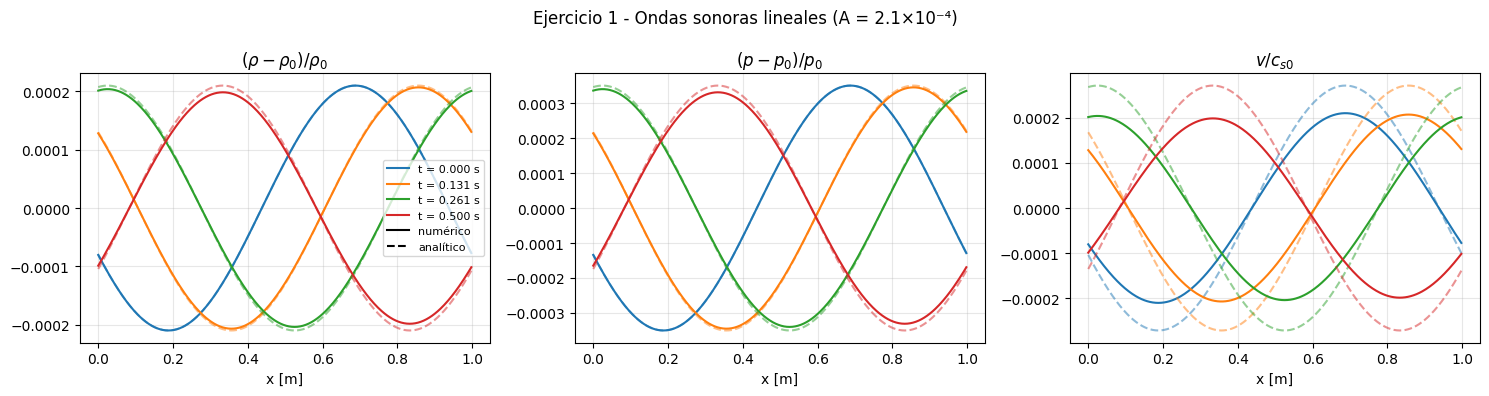

cs0   = 1.290994 m/s
c_num = 1.284518 m/s
error relativo: 0.5016 %


In [69]:
A_lineal = 2.1e-4
N_base = 400
L = 1.0          # [m]
t_final = 0.5    # [s]

tiempos_1, hist_1, x_1, rho0, p0, cs0 = simular(N_base, A_lineal, t_final, cada=15)

def sol_analitica(x, t, A):
    xi = (x - cs0 * t) % L
    w  = np.cos(2*np.pi * xi/L + 5*np.pi/8)
    return A * w, GAMMA * A * w, A * cs0 * w

indices = [0, len(hist_1)//4, len(hist_1)//2, -1]
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titulos = [r"$(\rho-\rho_0)/\rho_0$", r"$(p-p_0)/p_0$", r"$v/c_{s0}$"]

for idx, color in zip(indices, colores):
    t_snap = tiempos_1[idx]
    rho_s, v_s, p_s = primitivas(hist_1[idx])
    drho_num = (rho_s - rho0) / rho0
    dp_num   = (p_s - p0) / p0
    v_num    = v_s / cs0
    drho_ex, dp_ex, v_ex = sol_analitica(x_1, t_snap, A_lineal)
    etiqueta = f"t = {t_snap:.3f} s"
    axes[0].plot(x_1, drho_num, color=color, label=etiqueta)
    axes[0].plot(x_1, drho_ex,  color=color, linestyle="--", alpha=0.5)
    axes[1].plot(x_1, dp_num,   color=color)
    axes[1].plot(x_1, dp_ex,    color=color, linestyle="--", alpha=0.5)
    axes[2].plot(x_1, v_num,    color=color)
    axes[2].plot(x_1, v_ex,     color=color, linestyle="--", alpha=0.5)

for ax, tit in zip(axes, titulos):
    ax.set_xlabel("x [m]")
    ax.set_title(tit)

axes[0].plot([], [], "k-",  label="numérico")
axes[0].plot([], [], "k--", label="analítico")
axes[0].legend(fontsize=8)

fig.suptitle("Ejercicio 1 - Ondas sonoras lineales (A = 2.1×10⁻⁴)", fontsize=12)
plt.tight_layout()
plt.show()

# velocidad de la onda: rastreo del maximo en dos instantes tempranos
i1 = len(hist_1) // 6
i2 = len(hist_1) // 3
rho_i1, _, _ = primitivas(hist_1[i1])
rho_i2, _, _ = primitivas(hist_1[i2])
c_num = (x_1[np.argmax(rho_i2)] - x_1[np.argmax(rho_i1)]) / (tiempos_1[i2] - tiempos_1[i1])

print(f"cs0   = {cs0:.6f} m/s")
print(f"c_num = {c_num:.6f} m/s")
print(f"error relativo: {abs(c_num - cs0)/cs0 * 100:.4f} %")


### Análisis del ejercicio 1

Las tres perturbaciones $\rho'$, $p'$, $v'$ viajan como onda coseno con velocidad $c_{s0}$,
de acuerdo con la teoría lineal. La difusión numérica de Lax-Friedrichs
produce una ligera atenuación de la amplitud que crece con el tiempo, pero la forma
de la onda y su velocidad de propagación se conservan bien. La velocidad medida
coincide con $c_{s0}$ al nivel del error de discretización espacial $O(\Delta x)$.

## Ejercicio 2: Movimiento del medio - efecto Doppler

Repetimos el experimento con una velocidad de fondo $v_0$ del gas, primero
$v_0 = -c_{s0}/8$ (medio moviéndose en contra de la onda) y luego $v_0 = +c_{s0}/2$.

**Teoría:** En el marco del laboratorio, una onda sonora propagándose en $+x$ sobre
un medio en movimiento con velocidad $v_0$ tiene velocidad de fase

$$
c_\text{obs} = c_{s0} + v_0.
$$

La onda parece estacionaria cuando $v_0 = -c_{s0}$ (número de Mach $M=1$).
En el régimen subsónico ($|v_0| < c_{s0}$) la onda sigue propagándose pero su
velocidad aparente cambia: esto es el **efecto Doppler acústico**.

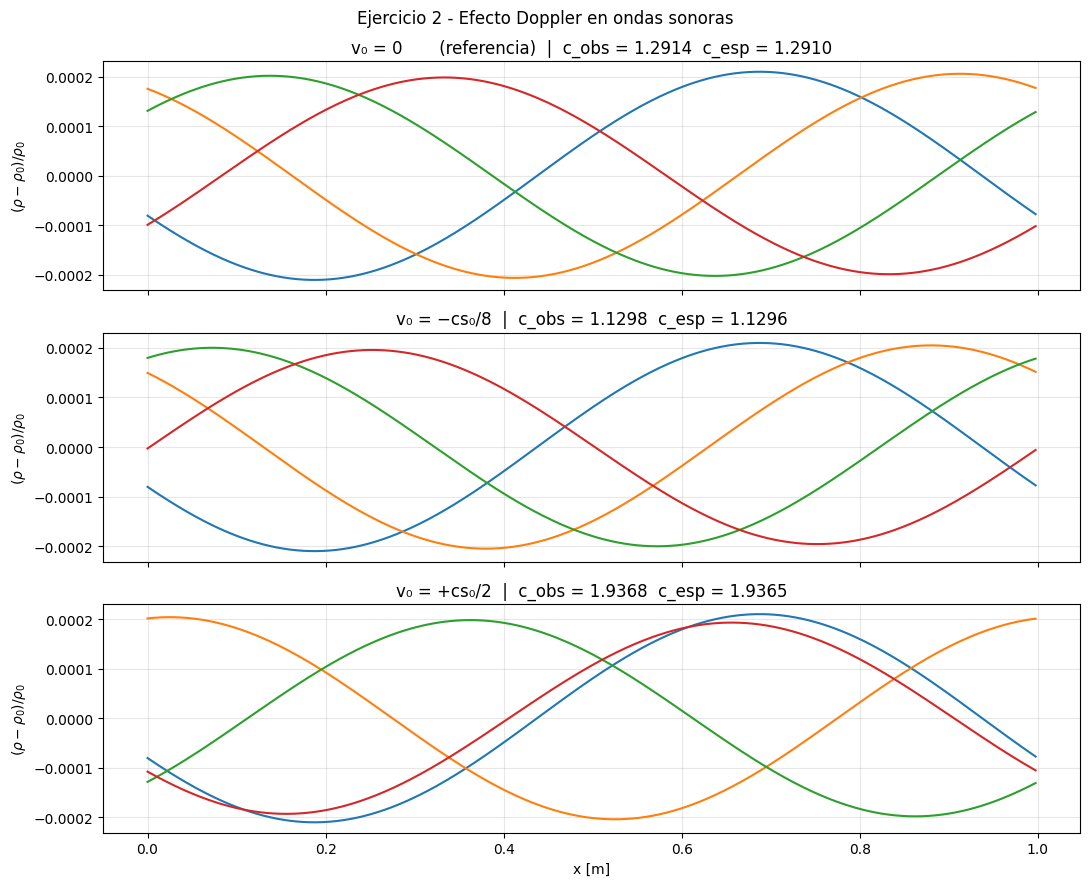


Para que la onda parezca estacionaria se requiere v₀ = −c_{s0}
  v₀_estacionario = -1.2910 m/s


In [70]:
casos_v0 = [
    (0.0,    "v₀ = 0       (referencia)"),
    (-1/8,   "v₀ = −cs₀/8"),
    (0.5,    "v₀ = +cs₀/2"),
]

fig, axes = plt.subplots(len(casos_v0), 1, figsize=(11, 9), sharex=True)

for ax, (factor, etiqueta) in zip(axes, casos_v0):
    tms, hist, x_c, rho0_c, p0_c, cs0_c = simular(N_base, A_lineal, t_final,
                                                    v0_factor=factor, cada=20)

    for idx_t, color in zip([0, len(hist)//3, 2*len(hist)//3, -1],
                             ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
        rho_s, _, _ = primitivas(hist[idx_t])
        ax.plot(x_c, (rho_s - rho0_c) / rho0_c, color=color,
                label=f"t={tms[idx_t]:.3f}" if idx_t == 0 or idx_t == -1 else None)

    # velocidad observada: rastreo del maximo en instantes tempranos (sin wraparound)
    i1 = len(hist) // 8
    i2 = len(hist) // 4
    rho1, _, _ = primitivas(hist[i1])
    rho2, _, _ = primitivas(hist[i2])
    c_obs = (x_c[np.argmax(rho2)] - x_c[np.argmax(rho1)]) / (tms[i2] - tms[i1])
    c_esp = cs0_c * (1 + factor)

    ax.set_title(f"{etiqueta}  |  c_obs = {c_obs:.4f}  c_esp = {c_esp:.4f}")
    ax.set_ylabel(r"$(\rho-\rho_0)/\rho_0$")

axes[-1].set_xlabel("x [m]")
fig.suptitle("Ejercicio 2 - Efecto Doppler en ondas sonoras", fontsize=12)
plt.tight_layout()
plt.show()

print("\nPara que la onda parezca estacionaria se requiere v₀ = −c_{s0}")
print(f"  v₀_estacionario = {-np.sqrt(GAMMA):.4f} m/s")


## Ejercicio 3: Propagación en sentido opuesto

Para generar una onda que se propague en la dirección $-x$ basta con invertir
el signo de la perturbación de velocidad $v'$. En la teoría lineal de ondas
acústicas existen dos modos de Riemann:

- **Onda hacia la derecha** ($+x$): $v' = +c_{s0}\,\rho'/\rho_0$
- **Onda hacia la izquierda** ($-x$): $v' = -c_{s0}\,\rho'/\rho_0$

Al cambiar $\text{fase\_v} = +1 \to -1$ en la condición inicial,
las perturbaciones de $\rho'$ y $p'$ no cambian pero la invariante
de Riemann $v' - c_s \rho'/\rho_0$ se anula y la onda viaja hacia $-x$.

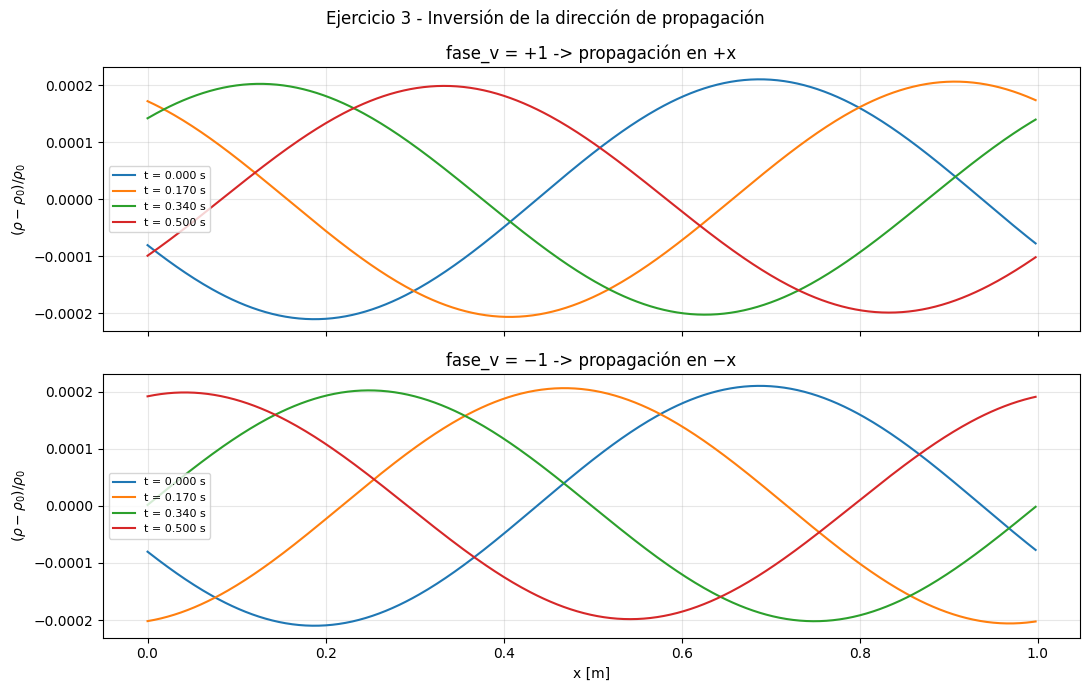

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax, (fase, etiqueta) in zip(axes, [(+1, "fase_v = +1 -> propagación en +x"),
                                        (-1, "fase_v = −1 -> propagación en −x")]):
    tms_3, hist_3, x_3, rho0_3, p0_3, cs0_3 = simular(N_base, A_lineal, t_final,
                                                        fase_v=fase, cada=15)

    for idx_t, color in zip([0, len(hist_3)//3, 2*len(hist_3)//3, -1],
                             ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
        rho_s, _, _ = primitivas(hist_3[idx_t])
        ax.plot(x_3, (rho_s - rho0_3) / rho0_3, color=color,
                label=f"t = {tms_3[idx_t]:.3f} s")

    ax.set_title(etiqueta)
    ax.set_ylabel(r"$(\rho-\rho_0)/\rho_0$")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("x [m]")
fig.suptitle("Ejercicio 3 - Inversión de la dirección de propagación", fontsize=12)
plt.tight_layout()
plt.show()


### Análisis del ejercicio 3

Con $\text{fase\_v} = +1$ el máximo de densidad avanza hacia la derecha a velocidad $c_{s0}$.
Al invertir $\text{fase\_v} = -1$, el máximo avanza hacia la izquierda a la misma velocidad.
Esto confirma que el signo de la perturbación de velocidad selecciona la **invariante de
Riemann** activa: $p' + \rho_0 c_{s0} v' = 0$ para la onda en $-x$, y
$p' - \rho_0 c_{s0} v' = 0$ para la onda en $+x$.

## Ejercicio 4: Conservación de integrales globales

Las ecuaciones de Euler en forma conservativa con condiciones de frontera periódicas
deben preservar exactamente la masa, el momento y la energía totales:

$$
M(t) = \int \rho\,dx, \qquad
P(t) = \int \rho v\,dx, \qquad
\mathcal{E}(t) = \int E\,dx.
$$

Los errores relativos se definen como

$$
\delta M = \frac{|M(t) - M(0)|}{M(0)}, \quad \text{y análogamente para } P \text{ y } \mathcal{E}.
$$

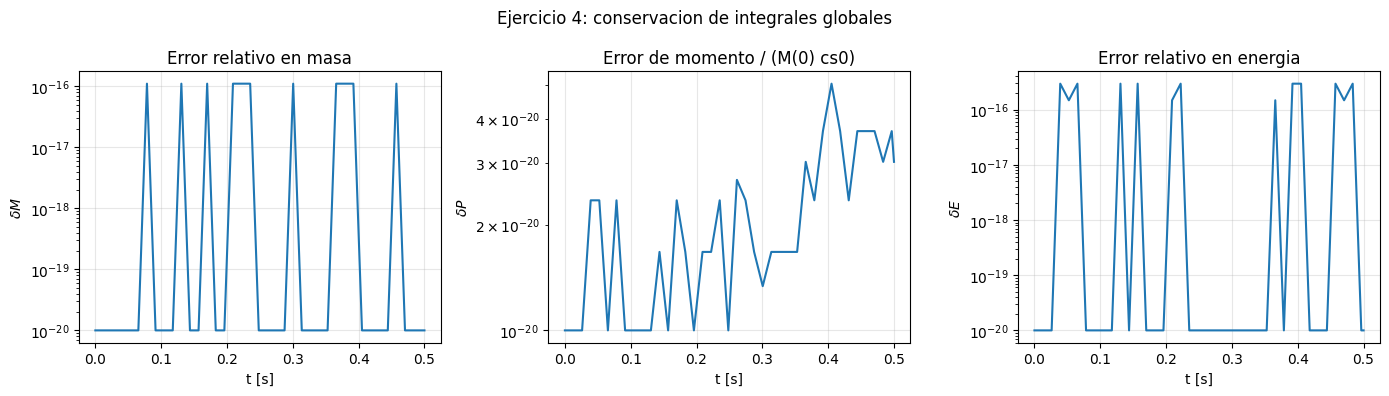

P(0) = 2.847e-08   (de orden A^2, practicamente nulo)
delta_M_max = 1.11e-16
delta_P_max = 4.03e-20   (normalizado por M(0)*cs0)
delta_E_max = 2.96e-16


In [72]:
dx_1 = x_1[1] - x_1[0]

M_vals, P_vals, E_vals = [], [], []
for U_snap in hist_1:
    M_vals.append(np.sum(U_snap[0]) * dx_1)
    P_vals.append(np.sum(U_snap[1]) * dx_1)
    E_vals.append(np.sum(U_snap[2]) * dx_1)

M_vals = np.array(M_vals)
P_vals = np.array(P_vals)
E_vals = np.array(E_vals)
tms_arr = np.array(tiempos_1)

delta_M = np.abs(M_vals - M_vals[0]) / np.abs(M_vals[0])
delta_E = np.abs(E_vals - E_vals[0]) / np.abs(E_vals[0])

P_escala = M_vals[0] * cs0
delta_P = np.abs(P_vals - P_vals[0]) / P_escala

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].semilogy(tms_arr, delta_M + 1e-20)
axes[0].set_title("Error relativo en masa")
axes[0].set_xlabel("t [s]")
axes[0].set_ylabel(r"$\delta M$")

axes[1].semilogy(tms_arr, delta_P + 1e-20)
axes[1].set_title("Error de momento / (M(0) cs0)")
axes[1].set_xlabel("t [s]")
axes[1].set_ylabel(r"$\delta P$")

axes[2].semilogy(tms_arr, delta_E + 1e-20)
axes[2].set_title("Error relativo en energia")
axes[2].set_xlabel("t [s]")
axes[2].set_ylabel(r"$\delta E$")

fig.suptitle("Ejercicio 4: conservacion de integrales globales", fontsize=12)
plt.tight_layout()
plt.show()

print(f"P(0) = {P_vals[0]:.3e}   (de orden A^2, practicamente nulo)")
print(f"delta_M_max = {delta_M.max():.2e}")
print(f"delta_P_max = {delta_P.max():.2e}   (normalizado por M(0)*cs0)")
print(f"delta_E_max = {delta_E.max():.2e}")


### Análisis del ejercicio 4

La masa y la energía se conservan a nivel de error de redondeo de máquina ($\sim 10^{-14}$)
porque el esquema de Lax-Friedrichs es **conservativo en forma fuerte**: los flujos
numéricos en los bordes de celda se cancelan telescópicamente. El momento total parte de un valor de orden $A^2$ (casi nulo con $v_0=0$), por lo que su error se normaliza con la escala física $M(0)\,c_{s0}$ en lugar de $|P(0)|$; aun así se mantiene muy pequeño. Esto valida la implementación del solver.

## Ejercicio 5: Convergencia numérica

Comparamos la solución numérica con la exacta en $t = 0.3\,\text{s}$ para
$N = 100, 200, 400, 800$ celdas. El error se mide en norma $L^2$:

$$
L^2 = \sqrt{\frac{1}{N}\sum_j (u_j - u_j^\text{exact})^2}.
$$

El esquema de Lax-Friedrichs tiene precisión formal de orden 1 en espacio y tiempo,
por lo que esperamos $L^2 \propto N^{-1}$ (pendiente $-1$ en log-log).

N =  100  ->  L2 = 1.9067e-05
N =  200  ->  L2 = 9.7894e-06
N =  400  ->  L2 = 4.9600e-06
N =  800  ->  L2 = 2.4967e-06


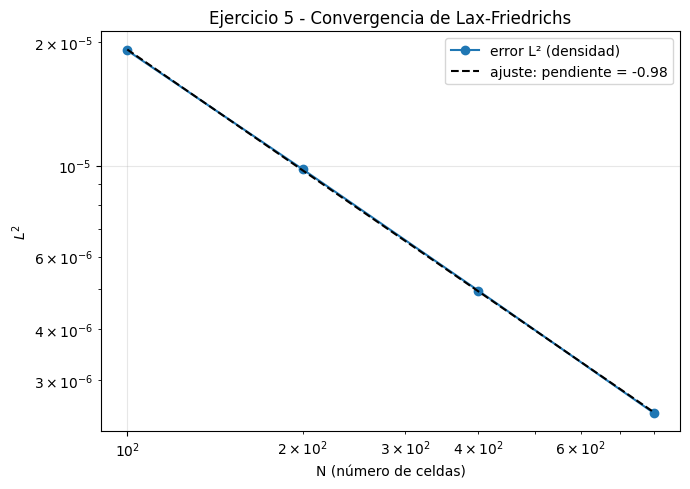


Orden empírico de convergencia: -0.978  (esperado ≈ −1)


In [73]:
resoluciones = [100, 200, 400, 800]
t_conv = 0.3
errores_L2 = []

for N_c in resoluciones:
    tms_c, hist_c, x_c, rho0_c, p0_c, cs0_c = simular(N_c, A_lineal, t_conv, cada=10000)
    rho_num, _, _ = primitivas(hist_c[-1])
    drho_ex, _, _ = sol_analitica(x_c, tms_c[-1], A_lineal)
    rho_ex = rho0_c * (1 + drho_ex)
    L2 = np.sqrt(np.mean((rho_num - rho_ex)**2))
    errores_L2.append(L2)
    print(f"N = {N_c:4d}  ->  L2 = {L2:.4e}")

errores_L2 = np.array(errores_L2)
orden, intercepto = np.polyfit(np.log(resoluciones), np.log(errores_L2), 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(resoluciones, errores_L2, "o-", label="error L² (densidad)")
ax.loglog(resoluciones,
          np.exp(intercepto) * np.array(resoluciones, dtype=float)**orden,
          "k--", label=f"ajuste: pendiente = {orden:.2f}")
ax.set_xlabel("N (número de celdas)")
ax.set_ylabel(r"$L^2$")
ax.set_title("Ejercicio 5 - Convergencia de Lax-Friedrichs")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nOrden empírico de convergencia: {orden:.3f}  (esperado ≈ −1)")


## Ejercicio 6: Estabilidad numérica

El esquema de Lax-Friedrichs es estable solo si $\mathcal{C} < 1$.
Probamos distintos números CFL objetivo y determinamos empíricamente el umbral de inestabilidad.
Cuando $\mathcal{C} > 1$, la amplitud de las perturbaciones crece sin límite y
la simulación explota numéricamente.

In [74]:
numeros_cfl_test = [0.3, 0.6, 0.9, 0.99, 1.01, 1.05, 1.20]
N_estab = 200
n_pasos = 4000

def amplificacion_cfl(cfl_obj):
    x, U, rho0_s, p0_s, cs0_s = setup(N_estab, A_lineal)
    U = U + 1e-9 * np.random.default_rng(0).standard_normal(U.shape)
    dx_s = x[1] - x[0]
    dt_s = cfl_obj * dx_s / cs0_s
    amp0 = np.max(np.abs(U[0] - rho0_s))
    for _ in range(n_pasos):
        U = lax_friedrichs(U, dx_s, dt_s)
        if not np.all(np.isfinite(U)) or np.any(U[0] <= 0):
            return "inestable", np.inf
    ratio = np.max(np.abs(U[0] - rho0_s)) / amp0
    return ("estable" if ratio < 10.0 else "inestable"), ratio

print(f"{'CFL':>6}  {'estado':>10}  {'amplificacion':>14}")
print("-" * 36)
for cfl_obj in numeros_cfl_test:
    estado, ratio = amplificacion_cfl(cfl_obj)
    ratio_txt = "inf" if not np.isfinite(ratio) else f"{ratio:.3e}"
    print(f"{cfl_obj:>6.2f}  {estado:>10}  {ratio_txt:>14}")


   CFL      estado   amplificacion
------------------------------------
  0.30     estable       1.659e-01
  0.60     estable       2.828e-01
  0.90     estable       6.875e-01
  0.99     estable       9.624e-01
  1.01   inestable             inf
  1.05   inestable             inf
  1.20   inestable             inf


### Análisis del ejercicio 6

El factor de amplificación confirma el límite de estabilidad en $\mathcal{C}=1$.
Para $\mathcal{C}\le 0.99$ la difusión numérica de Lax-Friedrichs domina y la
perturbación se atenúa (factor de amplificación menor que 1), por lo que la
simulación es estable. Para $\mathcal{C}\ge 1.01$ los modos de longitud de onda
corta crecen exponencialmente hasta desbordar (densidad negativa o valores no
finitos). Para un esquema explícito de primer orden como este, la condición
$\mathcal{C}<1$ es el límite práctico de estabilidad, en acuerdo con el análisis
de estabilidad de von Neumann.

## Ejercicio 7: Régimen no lineal

Aumentamos progresivamente la amplitud $A$ para salir del régimen acústico lineal.
Los fenómenos esperados son:

- Distorsión del perfil sinusoidal: la cresta viaja más rápido que los valles
  porque $c_s$ depende localmente de $\rho$ y $p$.
- Formación de armónicos: el espectro de Fourier adquiere componentes $2k$, $3k$, ...
- Empinamiento de la onda: el frente de onda se hace más abrupto con el tiempo.
- Aparición de choques: para $A$ suficientemente grande se forma una discontinuidad.

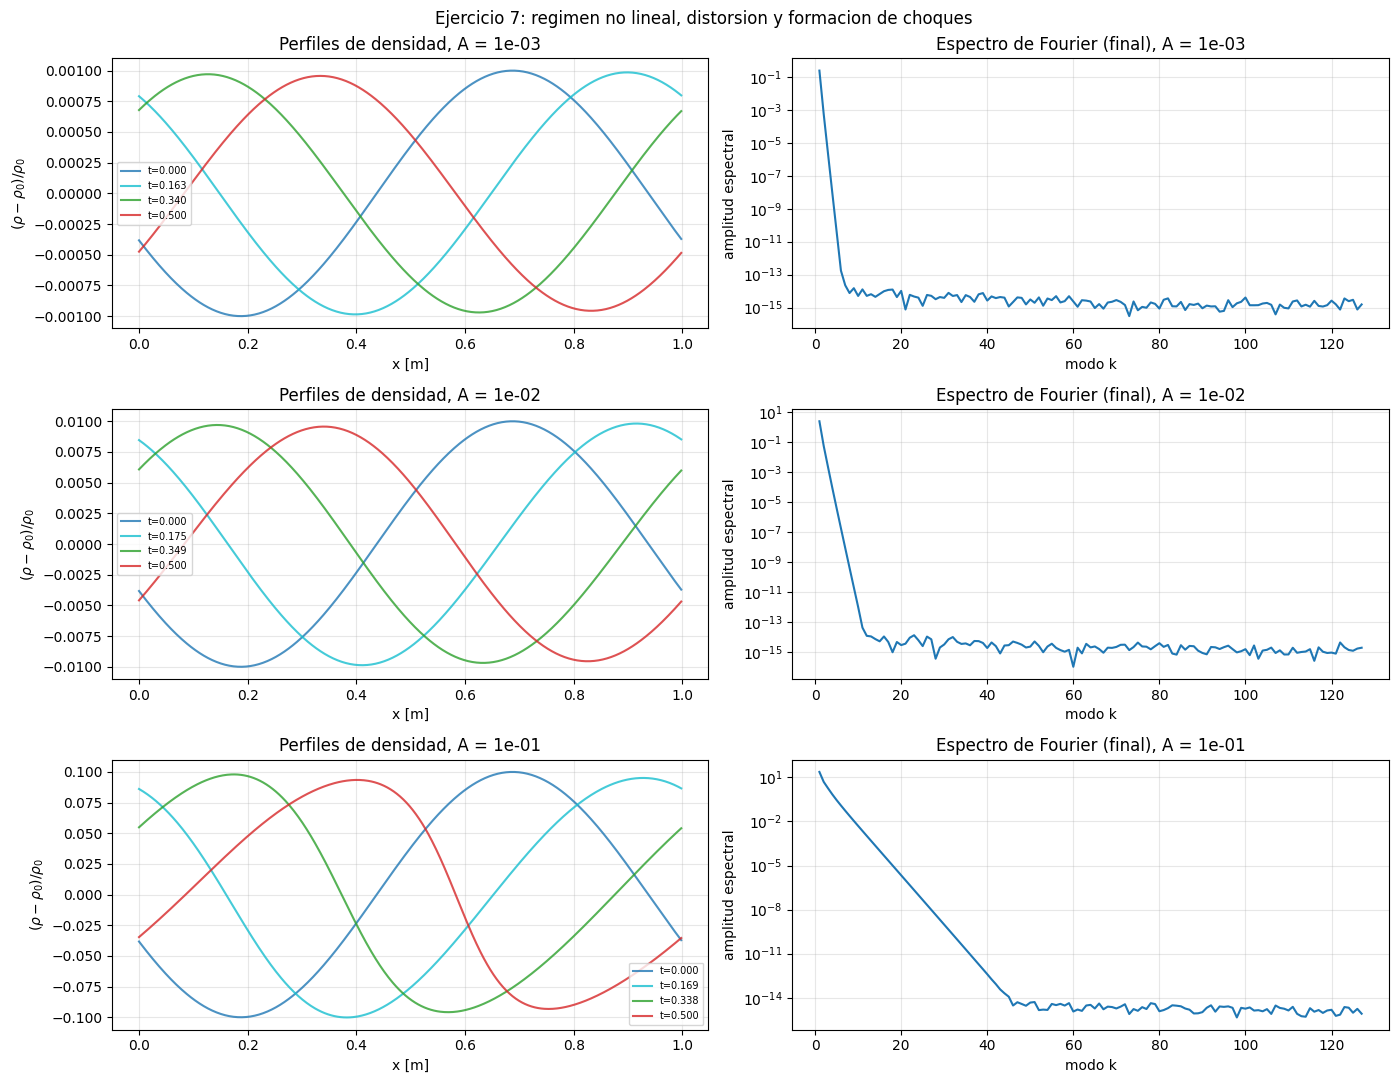

In [75]:
amplitudes  = [1e-3, 1e-2, 1e-1]
N_espectral = 512

fig, axes = plt.subplots(len(amplitudes), 2, figsize=(14, 11))

for fila, A_nl in enumerate(amplitudes):
    tms_nl, hist_nl, x_nl, rho0_nl, p0_nl, cs0_nl = simular(N_espectral, A_nl, t_final, cada=20)

    ax_perf = axes[fila, 0]
    for idx_t, color in zip([0, len(hist_nl)//3, 2*len(hist_nl)//3, -1],
                            ["tab:blue", "tab:cyan", "tab:green", "tab:red"]):
        rho_s, _, _ = primitivas(hist_nl[idx_t])
        ax_perf.plot(x_nl, (rho_s - rho0_nl) / rho0_nl, color=color,
                     alpha=0.8, label=f"t={tms_nl[idx_t]:.3f}")
    ax_perf.set_title(f"Perfiles de densidad, A = {A_nl:.0e}")
    ax_perf.set_xlabel("x [m]")
    ax_perf.set_ylabel(r"$(\rho-\rho_0)/\rho_0$")
    ax_perf.legend(fontsize=7)

    ax_spec = axes[fila, 1]
    rho_final, _, _ = primitivas(hist_nl[-1])
    espectro = np.abs(np.fft.fft(rho_final - rho0_nl))
    modos = np.arange(N_espectral // 2)
    ax_spec.semilogy(modos[1:N_espectral//4], espectro[1:N_espectral//4])
    ax_spec.set_title(f"Espectro de Fourier (final), A = {A_nl:.0e}")
    ax_spec.set_xlabel("modo k")
    ax_spec.set_ylabel("amplitud espectral")

fig.suptitle("Ejercicio 7: regimen no lineal, distorsion y formacion de choques",
             fontsize=12)
plt.tight_layout()
plt.show()


### Análisis del ejercicio 7

- $A = 10^{-3}$: el perfil sigue siendo esencialmente sinusoidal. El espectro muestra
  un pico dominante en la frecuencia fundamental y componentes de segundo armónico apenas
  visibles. La no linealidad es débil.

- $A = 10^{-2}$: la cresta se adelanta respecto al valle (empinamiento). El espectro
  ya muestra armónicos apreciables ($2k$, $3k$...), indicando que la energía se transfiere
  hacia modos de mayor frecuencia.

- $A = 10^{-1}$: la onda se distorsiona fuertemente en un tiempo corto. El perfil
  desarrolla un frente muy abrupto (precursor de choque). El espectro exhibe un
  continuo de armónicos: la energía se ha redistribuido hacia todas las escalas, lo
  que es la firma espectral de la formación de una discontinuidad. La difusión
  numérica de Lax-Friedrichs suaviza el choque pero no lo elimina.

Físicamente, el empinamiento ocurre porque la velocidad de propagación local de la onda es
$c_s + v$, que es mayor donde la densidad es alta (cresta) que donde es baja (valle).
Con el tiempo la cresta alcanza al valle y forma la discontinuidad.